## Visualize Train/Test Images
This notebook loads metadata for a specific dataset and displays random images from the train and test splits. Use it to inspect potential data leakage.

/tmp/ipykernel_3286812/2587405851.py:12: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_path)


Loaded 140488 entries
Columns: ['identity', 'path', 'date', 'orientation', 'species', 'split', 'dataset', 'cluster_id']
Filtered to dataset: IPanda50, 6874 entries
Train samples: 5499  Test samples: 1375
Found 48 individuals in both train and test splits.
Randomly selected individual: IPanda50_18_miaomiao


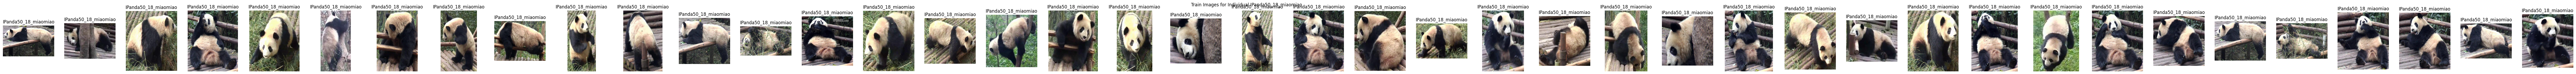

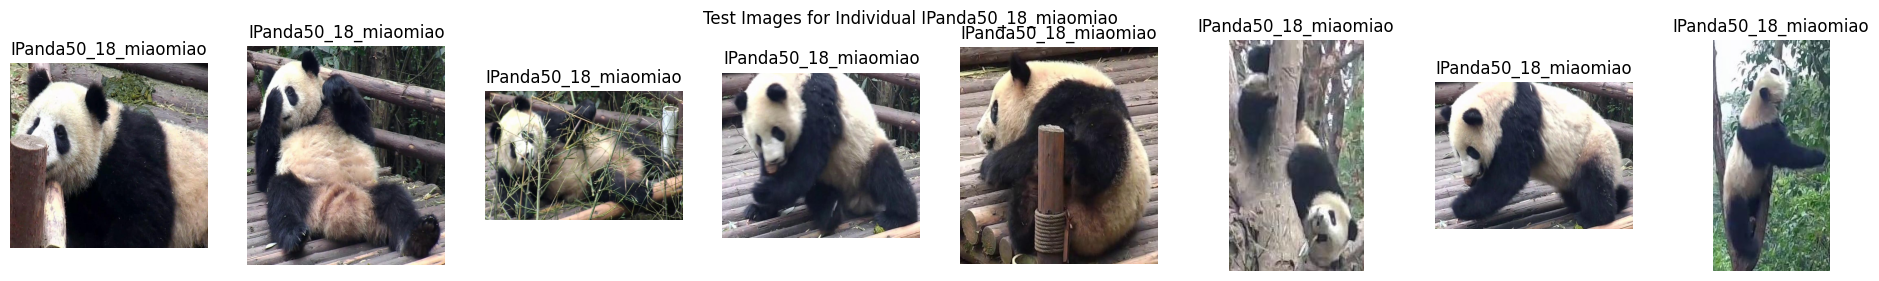

In [12]:
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


METADATA_PATH = Path('../data/wildlifedatasets/wildlifereid-10k/versions/7/metadata.csv')
DATA_ROOT = Path('../data/wildlifedatasets/wildlifereid-10k/versions/7/')

def visualize_random_individual(dataset_name, metadata_path=METADATA_PATH, data_root=DATA_ROOT):
    df = pd.read_csv(metadata_path)
    print('Loaded', len(df), 'entries')
    print('Columns:', df.columns.tolist())

    # Filter by dataset name
    df = df[df['dataset'] == dataset_name]
    print(f'Filtered to dataset: {dataset_name}, {len(df)} entries')

    # Split train and test
    train_df = df[df['split'].str.lower() == 'train']
    test_df = df[df['split'].str.lower() == 'test']
    print('Train samples:', len(train_df), ' Test samples:', len(test_df))

    # Find eligible IDs (present in both train and test)
    train_ids = set(train_df['identity'])
    test_ids = set(test_df['identity'])
    eligible_ids = list(train_ids & test_ids)
    print(f'Found {len(eligible_ids)} individuals in both train and test splits.')

    if not eligible_ids:
        print("No eligible individuals found for the specified criteria.")
        return

    selected_id = np.random.choice(eligible_ids)
    print(f'Randomly selected individual: {selected_id}')

    train_individual_df = train_df[train_df['identity'] == selected_id]
    test_individual_df = test_df[test_df['identity'] == selected_id]

    def show_images(df_subset, title):
        n = len(df_subset)
        if n == 0:
            print(f"No images found for {title}")
            return
        plt.figure(figsize=(3 * n, 3))
        for i, (_, row) in enumerate(df_subset.iterrows()):
            img_path = data_root / Path(row['path'])
            try:
                img = Image.open(img_path)
            except FileNotFoundError:
                print('Missing image:', img_path)
                continue
            plt.subplot(1, n, i + 1)
            plt.imshow(img)
            plt.title(row['identity'])
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

    show_images(train_individual_df, f'Train Images for Individual {selected_id}')
    show_images(test_individual_df, f'Test Images for Individual {selected_id}')

visualize_random_individual('IPanda50')

In [23]:
visualize_random_individual('ATRW')

Loading metadata from: ../data/wildlifedatasets/ATRW/versions/7/metadata.csv


FileNotFoundError: [Errno 2] No such file or directory: '../data/wildlifedatasets/ATRW/versions/7/metadata.csv'

In [19]:
# Determine train and test splits using the 'split' column
train_df = df[df['split'].str.lower() != 'test']
test_df = df[df['split'].str.lower() == 'test']
print('Train samples:', len(train_df), ' Test samples:', len(test_df))


Train samples: 109927  Test samples: 30561


In [20]:
def show_random_images(df_subset, title, n=5):
    sample = df_subset.sample(n=min(n, len(df_subset)), random_state=42)
    plt.figure(figsize=(3*n, 3))
    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = IMAGES_PATH / Path(row['path'])
        try:
            img = Image.open(img_path)
        except FileNotFoundError:
            print('Missing image:', img_path)
            continue
        plt.subplot(1, len(sample), i+1)
        plt.imshow(img)
        plt.title(row['identity'])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


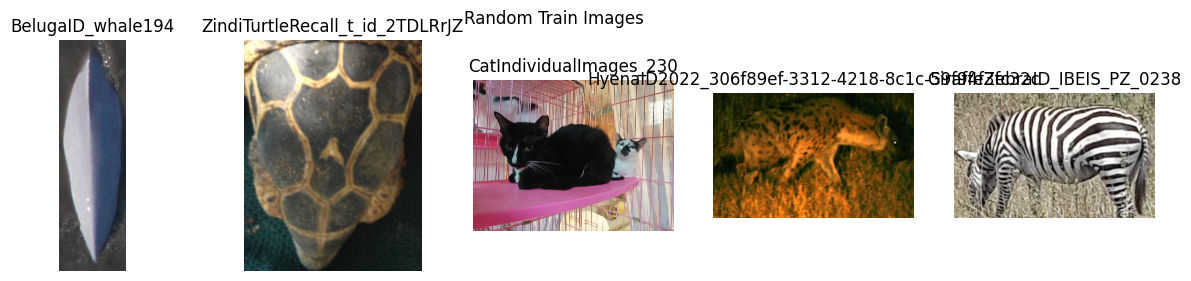

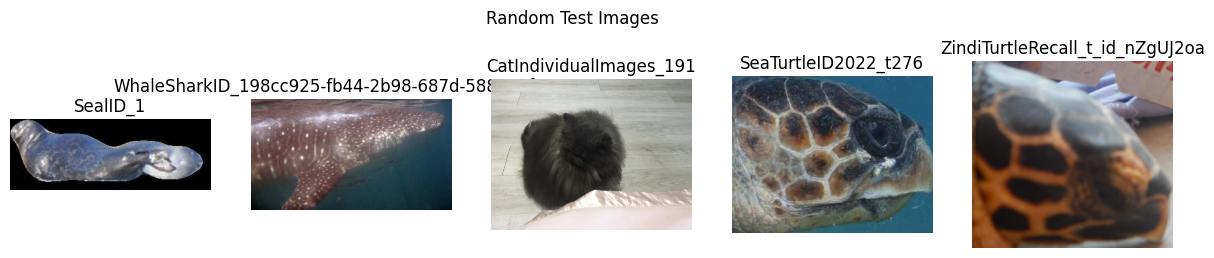

In [21]:
show_random_images(train_df, 'Random Train Images')
show_random_images(test_df, 'Random Test Images')
